# Lab 3: K-means rent classification and hyperparameter optimization

This notebook implements K-means **from scratch** with object-oriented Python, applies it to Swedish county rent and income data, chooses the number of clusters with a from-scratch silhouette grid search, and assigns three new unnamed regions to clusters.

> The assignment calls the file `rent_vs_inc.csv`; the supplied file is `inc_vs_rent.csv`. The latter is used here.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 2)
RANDOM_STATE = 42
DATA_PATH = Path('data/inc_vs_rent.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('inc_vs_rent.csv')  # convenient fallback


## Task 1 - Classification with K-means

### 1.1 Load and inspect the data

In [2]:
df = pd.read_csv(DATA_PATH, index_col=0)
df.head(10)

,year,region,Annual rent sqm,Avg yearly inc KSEK
0,2020,01 Stockholm county,1341,350.30
1,2020,03 Uppsala county,1303,306.92
2,2020,04 Södermanland county,1129,283.76
3,2020,05 Östergötland county,1144,289.50
4,2020,06 Jönköping county,1044,287.47
5,2020,07 Kronoberg county,1040,282.42
6,2020,08 Kalmar county,1008,278.20
7,2020,09 Gotland county,1120,270.56
8,2020,10 Blekinge county,1096,282.94
9,2020,12 Skåne county,1212,294.25


In [3]:
print(f'Rows: {len(df)}, columns: {df.shape[1]}')
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate regions:', int(df['region'].duplicated().sum()))
display(df.describe(include=[np.number]))

Rows: 21, columns: 4
Missing values: 0
Duplicate regions: 0


,year,Annual rent sqm,Avg yearly inc KSEK
count,21.0,21.00,21.00
mean,2020.0,1102.67,290.85
std,0.0,93.12,16.39
min,2020.0,994.00,270.56
25%,2020.0,1040.00,282.51
50%,2020.0,1096.00,287.47
75%,2020.0,1144.00,294.25
max,2020.0,1341.00,350.30


**Interpretation.** Each row represents one of Sweden's 21 counties in 2020. The two features used for clustering are annual rent per square metre and average yearly income in KSEK. The table contains no missing values or duplicate counties. Stockholm has visibly high rent and income relative to most counties, while most observations are concentrated at lower values. Because the task is unsupervised and has no ground-truth cluster labels, a conventional train/validation split is not used; cluster quality is instead compared internally using the silhouette coefficient.

### 1.2 Scatter plot

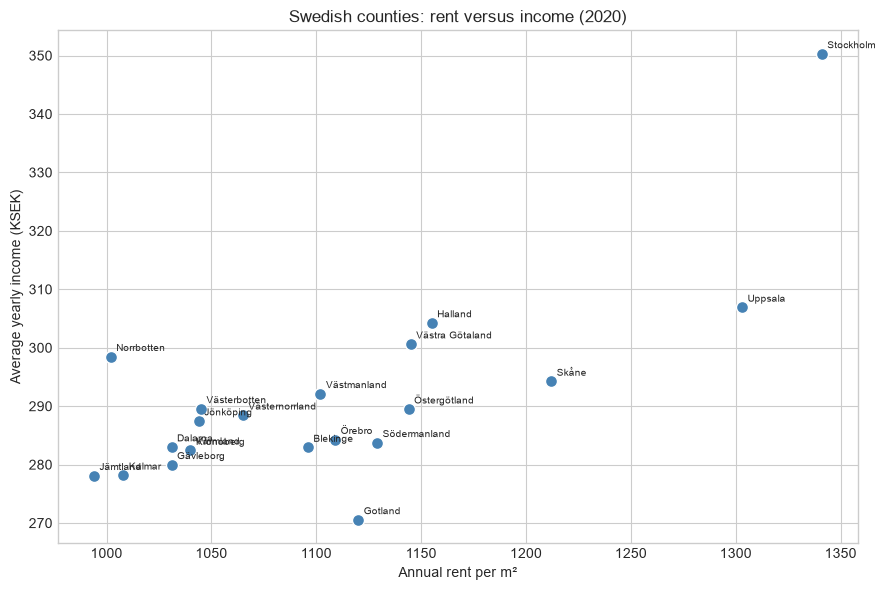

In [4]:
FEATURES = ['Annual rent sqm', 'Avg yearly inc KSEK']
X = df[FEATURES].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X[:, 0], X[:, 1], s=75, color='steelblue', edgecolor='white')
for _, row in df.iterrows():
    ax.annotate(row['region'].split(' ', 1)[1].replace(' county', ''),
                (row[FEATURES[0]], row[FEATURES[1]]), xytext=(4, 4),
                textcoords='offset points', fontsize=7)
ax.set(xlabel='Annual rent per m²', ylabel='Average yearly income (KSEK)',
       title='Swedish counties: rent versus income (2020)')
plt.tight_layout(); plt.show()

The scatter plot suggests a dense lower-rent group, a middle-rent group, and a few high-rent counties. Stockholm is the clearest high-value point. Since the features have different numeric ranges, raw-unit Euclidean distance is influenced more by rent. This notebook deliberately uses the assignment's raw coordinates so the supplied new points can be evaluated directly.

### 1.3 K-means implemented from scratch

In [5]:
class KMeansScratch:
    """K-means using Euclidean distance and sample-based random initialization."""
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-6, random_state=None):
        if n_clusters < 1:
            raise ValueError('n_clusters must be at least 1')
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    @staticmethod
    def _distances(X, centroids):
        return np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or self.n_clusters > len(X):
            raise ValueError('X must be 2D and n_clusters cannot exceed sample count')
        rng = np.random.default_rng(self.random_state)
        self.centroids_ = X[rng.choice(len(X), self.n_clusters, replace=False)].copy()
        for iteration in range(self.max_iter):
            distances = self._distances(X, self.centroids_)
            labels = distances.argmin(axis=1)
            new_centroids = np.empty_like(self.centroids_)
            for cluster in range(self.n_clusters):
                members = X[labels == cluster]
                if len(members):
                    new_centroids[cluster] = members.mean(axis=0)
                else:
                    # Re-seed an empty cluster with the currently worst represented point.
                    new_centroids[cluster] = X[distances.min(axis=1).argmax()]
            shift = np.linalg.norm(new_centroids - self.centroids_, axis=1).max()
            self.centroids_ = new_centroids
            if shift <= self.tol:
                break
        self.n_iter_ = iteration + 1
        self.labels_ = self.predict(X)
        self.inertia_ = float(np.sum((X - self.centroids_[self.labels_]) ** 2))
        return self

    def predict(self, X):
        if not hasattr(self, 'centroids_'):
            raise RuntimeError('Call fit before predict')
        X = np.asarray(X, dtype=float)
        return self._distances(X, self.centroids_).argmin(axis=1)

    def fit_predict(self, X):
        return self.fit(X).labels_

Converged in 2 iterations; inertia = 19415.92


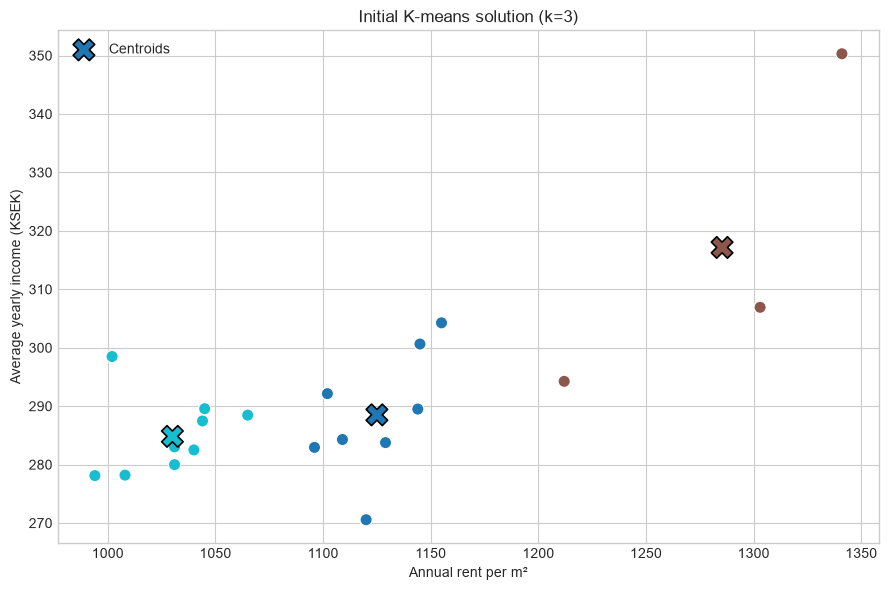

In [6]:
initial_model = KMeansScratch(n_clusters=3, max_iter=100, random_state=RANDOM_STATE).fit(X)
print(f'Converged in {initial_model.n_iter_} iterations; inertia = {initial_model.inertia_:.2f}')

fig, ax = plt.subplots(figsize=(9, 6))
points = ax.scatter(X[:, 0], X[:, 1], c=initial_model.labels_, cmap='tab10',
                    s=80, edgecolor='white')
ax.scatter(initial_model.centroids_[:, 0], initial_model.centroids_[:, 1],
           marker='X', s=240, c=np.arange(3), cmap='tab10', edgecolor='black',
           linewidth=1.2, label='Centroids')
ax.set(xlabel='Annual rent per m²', ylabel='Average yearly income (KSEK)',
       title='Initial K-means solution (k=3)')
ax.legend(); plt.tight_layout(); plt.show()

## Task 2 - Hyperparameter optimization

### 2.1 From-scratch silhouette coefficient and grid search

In [7]:
def average_intra_cluster_distance(X, labels, i):
    """a(i): mean distance from point i to other points in its cluster."""
    same = np.flatnonzero(labels == labels[i])
    same = same[same != i]
    if len(same) == 0:
        return 0.0
    return float(np.linalg.norm(X[same] - X[i], axis=1).mean())

def average_nearest_cluster_distance(X, labels, i):
    """b(i): smallest mean distance from point i to another cluster."""
    other_clusters = np.unique(labels[labels != labels[i]])
    means = [np.linalg.norm(X[labels == c] - X[i], axis=1).mean() for c in other_clusters]
    return float(min(means))

def silhouette_samples_scratch(X, labels):
    X, labels = np.asarray(X, float), np.asarray(labels)
    if len(np.unique(labels)) < 2:
        raise ValueError('Silhouette is undefined for a single cluster')
    scores = np.zeros(len(X))
    for i in range(len(X)):
        if np.sum(labels == labels[i]) == 1:
            scores[i] = 0.0  # standard convention for singleton clusters
            continue
        a_i = average_intra_cluster_distance(X, labels, i)
        b_i = average_nearest_cluster_distance(X, labels, i)
        scores[i] = (b_i - a_i) / max(a_i, b_i)
    return scores

def silhouette_score_scratch(X, labels):
    return float(silhouette_samples_scratch(X, labels).mean())

def grid_search_clusters(X, k_values=range(1, 11), random_state=42):
    results, models = [], {}
    for k in k_values:
        model = KMeansScratch(k, max_iter=100, random_state=random_state).fit(X)
        models[k] = model
        score = np.nan if k == 1 else silhouette_score_scratch(X, model.labels_)
        results.append({'k': k, 'silhouette': score, 'inertia': model.inertia_})
    return pd.DataFrame(results), models

grid_results, grid_models = grid_search_clusters(X)
display(grid_results.round(4))

,k,silhouette,inertia
0,1,NaN,178794.67
1,2,0.65,59587.42
2,3,0.63,19415.92
3,4,0.59,10561.98
4,5,0.49,7748.16
5,6,0.47,6446.59
6,7,0.44,5828.82
7,8,0.49,2745.50
8,9,0.32,2972.09
9,10,0.44,2279.25


Best k = 2, silhouette coefficient = 0.6521


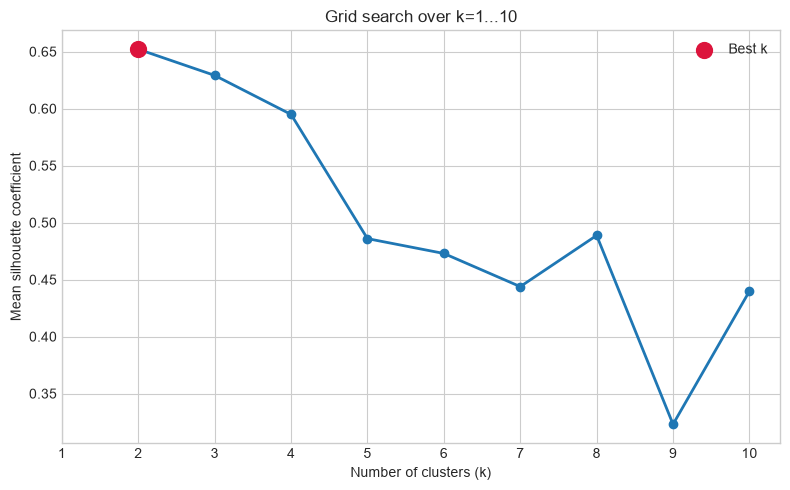

In [8]:
valid = grid_results.dropna(subset=['silhouette'])
optimal_k = int(valid.loc[valid['silhouette'].idxmax(), 'k'])
optimal_score = float(valid['silhouette'].max())
print(f'Best k = {optimal_k}, silhouette coefficient = {optimal_score:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(valid['k'], valid['silhouette'], marker='o', linewidth=2)
ax.scatter([optimal_k], [optimal_score], s=130, color='crimson', zorder=3, label='Best k')
ax.set(xticks=range(1, 11), xlabel='Number of clusters (k)',
       ylabel='Mean silhouette coefficient', title='Grid search over k=1...10')
ax.legend(); plt.tight_layout(); plt.show()

The silhouette coefficient is undefined for `k=1` because there is no other cluster from which to calculate `b(i)`; it is therefore shown as `NaN` and excluded from selection. The maximum score determines the optimal `k` among 2 through 10. A larger score means points are, on average, more cohesive within their own cluster and better separated from their nearest other cluster.

### 2.2 Plot the optimal clustering

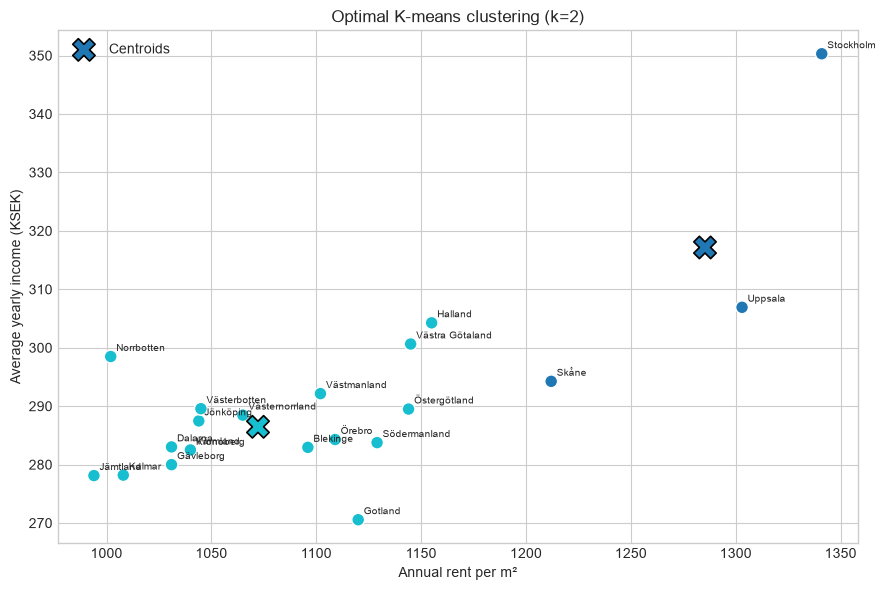

,count,mean_rent,mean_income,regions
cluster,,,,
0,3,1285.33,317.16,"Stockholm county, Uppsala county, Skåne county"
1,18,1072.22,286.46,"Södermanland county, Östergötland county, Jönk..."


In [9]:
optimal_model = grid_models[optimal_k]
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X[:, 0], X[:, 1], c=optimal_model.labels_, cmap='tab10',
           s=85, edgecolor='white')
ax.scatter(optimal_model.centroids_[:, 0], optimal_model.centroids_[:, 1],
           c=np.arange(optimal_k), cmap='tab10', marker='X', s=260,
           edgecolor='black', linewidth=1.2, label='Centroids')
for _, row in df.iterrows():
    ax.annotate(row['region'].split(' ', 1)[1].replace(' county', ''),
                (row[FEATURES[0]], row[FEATURES[1]]), xytext=(4, 4),
                textcoords='offset points', fontsize=7)
ax.set(xlabel='Annual rent per m²', ylabel='Average yearly income (KSEK)',
       title=f'Optimal K-means clustering (k={optimal_k})')
ax.legend(); plt.tight_layout(); plt.show()

cluster_summary = (df.assign(cluster=optimal_model.labels_)
                   .groupby('cluster')
                   .agg(count=('region', 'size'),
                        mean_rent=('Annual rent sqm', 'mean'),
                        mean_income=('Avg yearly inc KSEK', 'mean'),
                        regions=('region', lambda s: ', '.join(s.str.replace(r'^\d+ ', '', regex=True)))))
display(cluster_summary)

Cluster numbers are arbitrary identifiers rather than ordered classes. The summary above gives them meaning through their centroid levels and member counties. The solution separates counties mainly along annual rent, which has the larger numerical scale.

### 2.3 Classify and plot the three unnamed regions

,new_region,Annual rent sqm,Avg yearly inc KSEK,predicted_cluster
0,Region A,1010.0,320.12,1
1,Region B,1258.0,320.00,0
2,Region C,980.0,292.40,1


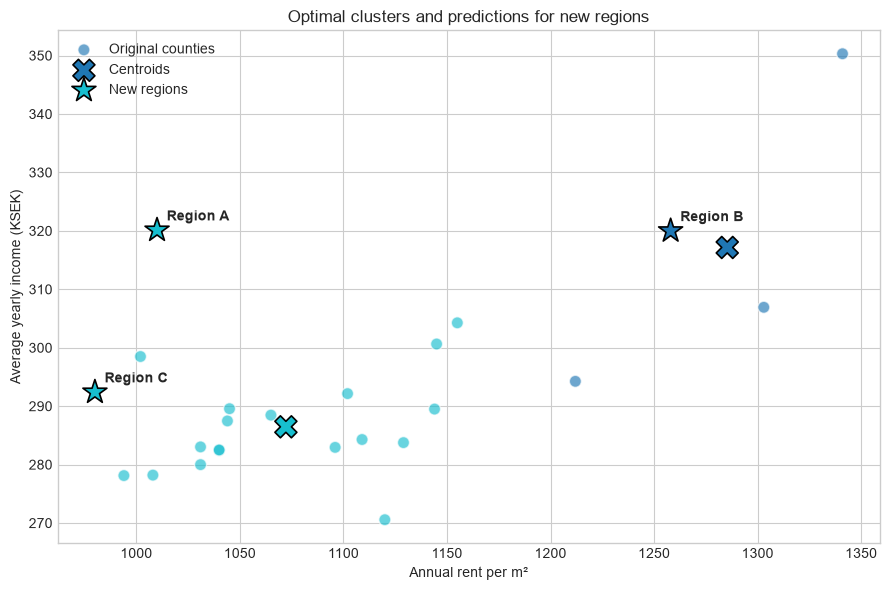

In [10]:
new_regions = np.array([[1010, 320.12], [1258, 320.00], [980, 292.40]])
new_labels = optimal_model.predict(new_regions)
predictions = pd.DataFrame(new_regions, columns=FEATURES)
predictions.insert(0, 'new_region', ['Region A', 'Region B', 'Region C'])
predictions['predicted_cluster'] = new_labels
display(predictions)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X[:, 0], X[:, 1], c=optimal_model.labels_, cmap='tab10',
           s=75, alpha=.65, edgecolor='white', label='Original counties')
ax.scatter(optimal_model.centroids_[:, 0], optimal_model.centroids_[:, 1],
           c=np.arange(optimal_k), cmap='tab10', marker='X', s=250,
           edgecolor='black', linewidth=1.2, label='Centroids')
ax.scatter(new_regions[:, 0], new_regions[:, 1], c=new_labels, cmap='tab10',
           vmin=0, vmax=max(optimal_k - 1, 1), marker='*', s=330,
           edgecolor='black', linewidth=1.2, label='New regions')
for name, (x, y) in zip(predictions['new_region'], new_regions):
    ax.annotate(name, (x, y), xytext=(7, 7), textcoords='offset points', weight='bold')
ax.set(xlabel='Annual rent per m²', ylabel='Average yearly income (KSEK)',
       title='Optimal clusters and predictions for new regions')
ax.legend(); plt.tight_layout(); plt.show()

**Evaluation.** The assignments are geometrically consistent with the nearest-centroid rule: each star appears in or near the cloud represented by its assigned centroid. Region B has high rent and is placed with the high-rent group; Region C is close to the low-rent group; and Region A combines low rent with unusually high income. That last point is less typical of its nearby counties and should be interpreted cautiously. Because there are no true labels, this visual and silhouette-based assessment measures plausibility, not predictive accuracy.

## Conclusion

The complete workflow loads and explores the county data, implements K-means and the silhouette coefficient without using a library clustering implementation, selects the best cluster count over the requested grid, and assigns new points by their nearest learned centroid. The result is reproducible through a fixed random seed. A useful extension would compare raw-unit clustering with standardized features, because feature scaling changes the meaning of Euclidean distance.